# Vokabeltrainer - quick demo

Small notebook showing how to use the package's public API directly
(instead of the CLI) - loading the vocabulary, running a couple of
reviews through the scheduler, and looking at stats/plots.


In [1]:
import sys

sys.path.insert(0, "../src")  # only needed if the package isn't installed in this kernel

from datetime import date, timedelta

from vokabeltrainer import categories, default_dataset_path, load_cards, review
from vokabeltrainer.stats import save_stats_plot, summarize


## Load the bundled vocabulary

In [2]:
cards = load_cards(default_dataset_path())
print(f"{len(cards)} cards across {len(categories(cards))} categories")
categories(cards)


139 cards across 10 categories


['adjectives',
 'colors',
 'family',
 'food',
 'greetings',
 'numbers',
 'time',
 'travel',
 'university',
 'verbs']

In [3]:
verbs = [c for c in cards if c.category == "verbs"]
for c in verbs[:8]:
    print(f"{c.german:15s} {c.grammar_hint():12s} -> {c.english}")


helfen          (+Dativ)     -> to help
danken          (+Dativ)     -> to thank
folgen          (+Dativ)     -> to follow
gratulieren     (+Dativ)     -> to congratulate
gefallen        (+Dativ)     -> to like/please
gehören         (+Dativ)     -> to belong to
antworten       (+Dativ)     -> to answer
vertrauen       (+Dativ)     -> to trust


## Simulate a few days of reviews

Instead of typing answers interactively (like the CLI's `study` command
does), we can call `review()` directly - handy for testing or, like here,
for demonstrating how the due date moves further out the better you know
a card.


In [4]:
card = verbs[0]
today = date(2026, 1, 1)
print(f"studying: {card.german} -> {card.english}")

for day_offset, quality in enumerate([5, 4, 5, 3]):
    today = date(2026, 1, 1) + timedelta(days=day_offset * 3)
    review(card, quality=quality, today=today)
    print(
        f"day {today}: quality={quality} -> next due {card.due_date}, "
        f"interval={card.interval_days}d, ease={card.ease_factor:.2f}"
    )


studying: helfen -> to help
day 2026-01-01: quality=5 -> next due 2026-01-02, interval=1d, ease=2.60
day 2026-01-04: quality=4 -> next due 2026-01-10, interval=6d, ease=2.60
day 2026-01-07: quality=5 -> next due 2026-01-23, interval=16d, ease=2.70
day 2026-01-10: quality=3 -> next due 2026-02-22, interval=43d, ease=2.56


Notice how the interval grows each time you recall the card well - that's
the whole point of spaced repetition: less time spent on words you already
know, more time on the ones you don't.


## Stats from a (simulated) review history

In [5]:
import random

random.seed(7)

history = []
start = date(2026, 2, 1)
for day_offset in range(10):
    day = start + timedelta(days=day_offset)
    for c in random.sample(cards, 12):
        quality = random.choice([2, 3, 4, 4, 5])
        history.append((c.card_id, quality, day.isoformat()))

summary = summarize(cards, history)
print(f"total reviews: {summary.total_reviews}")
print(f"overall accuracy: {summary.accuracy:.0%}")
print(f"weakest category: {summary.weakest_category}")
summary.accuracy_by_category


total reviews: 120
overall accuracy: 76%
weakest category: colors


{'adjectives': 0.8125,
 'colors': 0.5,
 'family': 0.75,
 'food': 0.8,
 'greetings': 0.7777777777777778,
 'numbers': 0.8333333333333334,
 'time': 0.625,
 'travel': 0.7777777777777778,
 'university': 0.7777777777777778,
 'verbs': 0.75}

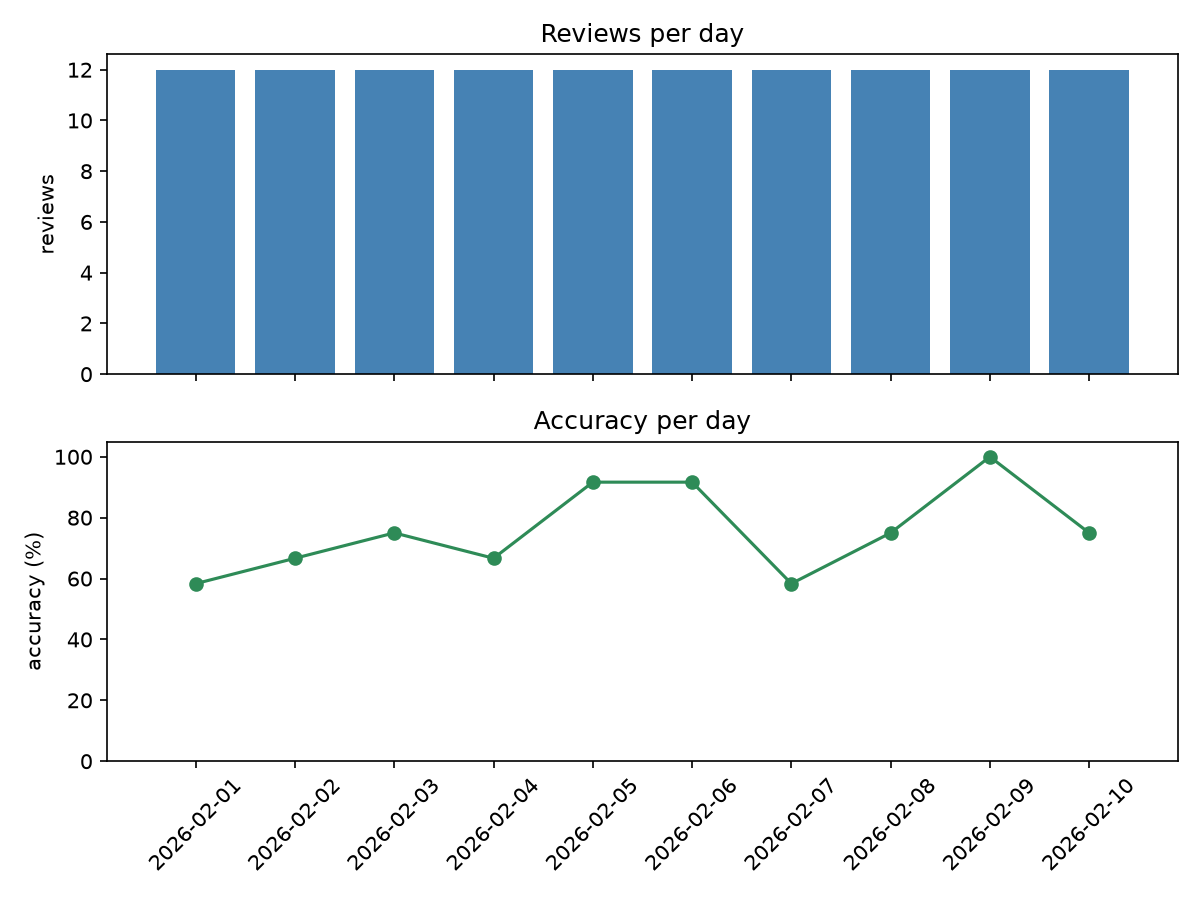

In [6]:
from IPython.display import Image

save_stats_plot(history, "../plots/demo_notebook_stats.png")
Image("../plots/demo_notebook_stats.png")
